In [311]:
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms 

In [312]:
import gc

gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_allocated() / 1024**2, "MB")

1921.49609375 MB


In [313]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [314]:
import torch
import torch.nn as nn

# Эти константы — стандарт для VGG
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(DEVICE)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(DEVICE)

class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        # .view(-1, 1, 1) нужно, чтобы тензор [3] стал [3, 1, 1] 
        # и его можно было умножить на картинку [3, H, W]
        self.mean = mean.clone().detach().view(-1, 1, 1)
        self.std = std.clone().detach().view(-1, 1, 1)

    def forward(self, img):
        return (img - self.mean) / self.std

In [315]:
vgg = models.vgg16(pretrained=True).features #берём без полносвязных слоёв
vgg = vgg.to(DEVICE)
vgg.eval()

normalization = Normalization(cnn_normalization_mean, cnn_normalization_std).to(DEVICE)


for param in vgg.parameters():
    param.requires_grad = False

print(vgg)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [316]:
def load_image(path, max_size = 512):
    image = Image.open(path).convert("RGB") #ТАК КАК ВГГ РАБОТАЕТ В РГБ

    transform = transforms.Compose([
    transforms.Resize(max_size),
    transforms.ToTensor(),
    ])

    image = transform(image).unsqueeze(0) #dobav batch 

    return image.to(DEVICE)

content = load_image("style\content.jpg")
style = load_image("style\style5.jpg")

<>:13: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\s'
C:\Users\semen\AppData\Local\Temp\ipykernel_28412\748083919.py:13: SyntaxWarning: invalid escape sequence '\c'
  content = load_image("style\content.jpg")
C:\Users\semen\AppData\Local\Temp\ipykernel_28412\748083919.py:14: SyntaxWarning: invalid escape sequence '\s'
  style = load_image("style\style5.jpg")


In [317]:
def get_features(x, model):
    layers = {
        '0': 'conv1_1',
        '5': 'conv2_1',
        '10': 'conv3_1',
        '19': 'conv4_1',
        '28': 'conv5_1'
    }

    features = {}
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    
    return features

In [318]:
content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

In [319]:
def gram_matrix(tensor):
    _, c, h, w = tensor.size()
    tensor = tensor.view(c, h*w)
    gram = torch.mm(tensor, tensor.t())

    return gram

In [320]:
style_grams = {layer: gram_matrix(style_features[layer])
               for layer in style_features}

In [321]:
#target = content.clone().requires_grad_(True).to(DEVICE)
#optimizer = torch.optim.AdamW([target], lr = 0.005)

content_weight = 1e2
style_weight = 1e6
tv_weight = 1e-8
epoch = 300

In [322]:
style_weights = {
    'conv1_1': 0.3,
    'conv2_1': 0.5,
    'conv3_1': 0.5,
    'conv4_1': 8.8,
    'conv5_1': 10.0
}

In [323]:
def grad_norm(loss, x):
    grad = torch.autograd.grad(
        loss,
        x,
        retain_graph=True,
        create_graph=False
    )[0]

    return grad.norm()

In [324]:
import torch.nn.functional as F

target = nn.Parameter(content.clone())

optimizer = torch.optim.LBFGS(
    [target],
    lr=1
)

for i in range(50):

    def closure():

        optimizer.zero_grad()

        target_features = get_features(target, vgg)

        # ---------- content loss ----------

        content_loss = F.mse_loss(
            target_features['conv4_1'],
            content_features['conv4_1']
        )

        # ---------- style loss ----------

        style_loss = 0

        for layer in style_features:

            target_one_feature = target_features[layer]

            target_gram = gram_matrix(target_one_feature)
            style_gram = style_grams[layer]

            _, c, h, w = target_one_feature.shape

            layer_loss = F.mse_loss(
                target_gram,
                style_gram
            )

            style_loss = style_loss + (
                style_weights[layer] *
                layer_loss / (c * h * w)
            )

        # ---------- total ----------

        total_loss = (
            content_weight * content_loss +
            style_weight * style_loss
        )

        total_loss.backward()

        return total_loss

    loss = optimizer.step(closure)

    # clamp normalized tensor
    with torch.no_grad():

        mean = torch.tensor(
            [0.485, 0.456, 0.406]
        ).view(1,3,1,1).to(DEVICE)

        std = torch.tensor(
            [0.229, 0.224, 0.225]
        ).view(1,3,1,1).to(DEVICE)

        lower = (0 - mean) / std
        upper = (1 - mean) / std

        target.clamp_(lower, upper)

    print(f"Step {i}, Loss: {loss.item()}")

Step 0, Loss: 28988460.0
Step 1, Loss: 1582370.125
Step 2, Loss: 753237.375
Step 3, Loss: 535492.1875
Step 4, Loss: 432735.78125
Step 5, Loss: 158877.40625
Step 6, Loss: 125266.859375
Step 7, Loss: 111484.015625
Step 8, Loss: 102034.3671875
Step 9, Loss: 95209.5390625
Step 10, Loss: 89354.703125
Step 11, Loss: 84084.578125
Step 12, Loss: 79854.0078125
Step 13, Loss: 76188.171875
Step 14, Loss: 73541.9609375
Step 15, Loss: 71086.578125
Step 16, Loss: 69123.5234375
Step 17, Loss: 67442.171875
Step 18, Loss: 65982.2734375
Step 19, Loss: 64679.70703125
Step 20, Loss: 63537.2421875
Step 21, Loss: 62401.6171875
Step 22, Loss: 61360.56640625
Step 23, Loss: 60304.31640625
Step 24, Loss: 59303.640625
Step 25, Loss: 58355.10546875
Step 26, Loss: 57462.56640625
Step 27, Loss: 56659.703125
Step 28, Loss: 55891.65234375
Step 29, Loss: 55190.44921875
Step 30, Loss: 54532.8984375
Step 31, Loss: 54016.03515625
Step 32, Loss: 53554.69140625
Step 33, Loss: 53157.61328125
Step 34, Loss: 52805.66796875
St

In [325]:
# total_loss = 0
# layer_loss = 0 
# content_loss = 0

# for i in range(epoch):
#     style_loss = 0
#     target_features = get_features(target, vgg)

#     content_loss = torch.mean( target_features['conv4_1'] - content_features['conv4_1'])**2

#     for layer in style_features:
#         target_one_feature = target_features[layer]
#         target_gram = gram_matrix(target_one_feature)
#         style_gram = style_grams[layer]

#         _, c, h , w = target_one_feature.shape

#         layer_loss = torch.mean((target_gram - style_gram)**2)
#         style_loss += style_weights[layer] * layer_loss / (c*h*w)
    
#     total_loss = content_weight*content_loss + style_weight*style_loss

#     optimizer.zero_grad()
#     total_loss.backward()
#     optimizer.step()

#     print(f"Step {i}, Loss: {total_loss.item()}")

In [326]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(tensor.device)

    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48931473..1.5468583].


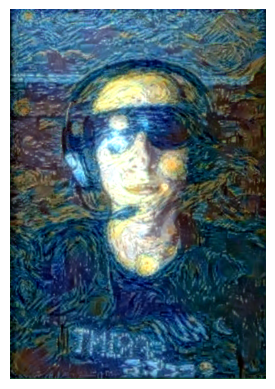

In [327]:
def imshow(tensor):
    image = tensor.clone().detach().cpu().squeeze(0)
    image = image.permute(1, 2, 0)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

imshow(target)

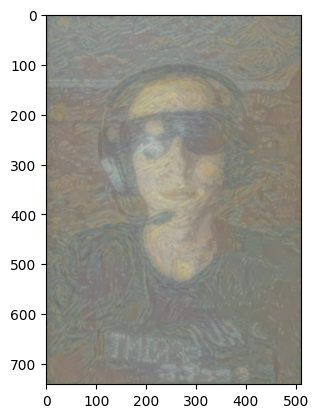

In [328]:
img = denormalize(target.detach())

plt.imshow(img.squeeze().permute(1,2,0).cpu())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48931473..1.5468583].


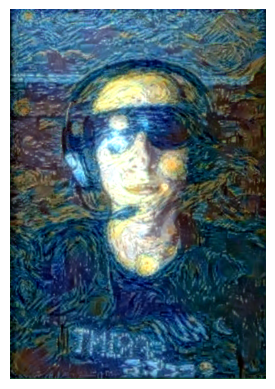

In [329]:
def imshow(tensor):
    image = tensor.clone().detach().cpu().squeeze(0)
    image = image.permute(1, 2, 0)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

imshow(target)